# Experimentos — Fases 0/2/3/4 (TASS 2018)

**Grupo:** Andrea · Julián · Arley — Procesamiento de Lenguaje Natural (UTB)

Este notebook ejecuta el flujo experimental sobre las **3 características léxicas del grupo**
(Fase 1, implementadas en `logic/`): `eh_count` (Julián), `vulgarity_count` (Arley) y
`diminutive_count` (Andrea). Cubre la **auditoría** (Fase 0), la **representación y unión** (Fase 2),
la **selección de algoritmo** (Fase 3) y la **evaluación** (Fase 4), sin fuga de información.

> Nota: es una base para que **Julián** la complemente con su parte. Corre de inicio a fin
> (Kernel → Restart & Run All) usando `data/tass/` del repositorio.

## 0. Configuración

In [1]:
import sys, re, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# raíz del repo (para importar logic/*) y datos
ROOT = Path.cwd()
if not (ROOT / "logic").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from logic.vulgarity_feature import VulgarityFeature
from logic.diminutive_feature import DiminutiveFeature

from scipy.sparse import hstack, csr_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import (f1_score, accuracy_score, classification_report, confusion_matrix)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

SEED = 42; np.random.seed(SEED)
DATA = ROOT / "data" / "tass"
tr = pd.read_csv(DATA / "tass2018_es_train.csv", encoding="utf-8")
te = pd.read_csv(DATA / "tass2018_es_test.csv", encoding="utf-8")
LAB = "sentiment/polarity/value"
le = LabelEncoder(); y_train = le.fit_transform(tr[LAB]); y_test = le.transform(te[LAB])
raw_train = tr["content"].astype(str); raw_test = te["content"].astype(str)
print("train", len(tr), "test", len(te), "| clases", le.classes_.tolist())
print("dist train:", {le.classes_[k]: int(v) for k,v in sorted(Counter(y_train).items())})

train 1008 test 506 | clases ['N', 'NEU', 'NONE', 'P']
dist train: {'N': 418, 'NEU': 133, 'NONE': 139, 'P': 318}


In [2]:
def clean_tweet(t):
    t = t.lower(); t = re.sub(r"https?://\S+|www\.\S+"," ",t); t = re.sub(r"@\w+"," ",t)
    t = re.sub(r"#","",t); t = re.sub(r"(.)\1{2,}",r"\1\1",t); return re.sub(r"\s+"," ",t).strip()

# Característica de Julián (interjección "eh") — se implementa aquí para el experimento
_EH = re.compile(r"\beh\b", re.IGNORECASE)
def eh_count(t): return float(len(_EH.findall(str(t))))

class GroupLexical(BaseEstimator, TransformerMixin):
    '''Une las 3 características del grupo -> matriz (n, 3), sobre texto crudo.'''
    names = ["eh_count", "vulgarity_count", "diminutive_count"]
    def fit(self, X, y=None): return self
    def transform(self, X, y=None):
        if hasattr(X, "tolist"): X = X.tolist()
        v, d = VulgarityFeature(), DiminutiveFeature()
        return np.asarray([[eh_count(t), v.count_vulgar(str(t)), d.count_diminutives(str(t))] for t in X], float)
print(GroupLexical().transform(["que puto ratito jajaja eh besitos!!"]) )

[[1. 1. 2.]]


## Fase 0 — Auditoría de las características existentes
Se auditan las **7 características** del extractor original del notebook: ¿constantes?, ¿proxies de la
longitud? (correlación con nº de tokens), ¿activación?

In [3]:
def orig7(text):
    s = str(text)
    return [len(re.findall(r"(.)´{2,}", s)),
            len(re.findall(r"j[aeiou]j[aeiou]j?[aeiou]?", s, re.I)),
            sum(1 for c in s if c.isupper())/(len(s)+1),
            len(re.findall(r"[!?]{2,}", s)),
            len(re.findall(r"\bh?(muy|super|súper|demasiado|bastante|extremadamente)\b", s, re.I)),
            len(s.split()),
            len(re.findall(r"\beh\b", s, re.I))]
on = ["elongated_count","laughter_count","caps_ratio","exc_que_rep","intensifiers","word_count","eh_count"]
O = np.array([orig7(t) for t in raw_train], float); tok = np.array([len(str(t).split()) for t in raw_train], float)
pd.DataFrame([{"característica":on[i],"constante":np.std(O[:,i])==0,
               "activación_%":round(float(np.mean(O[:,i]!=0))*100,1),
               "corr_longitud":round(float(np.corrcoef(O[:,i],tok)[0,1]),3) if np.std(O[:,i])>0 else 0.0}
              for i in range(7)])

,característica,constante,activación_%,corr_longitud
0,elongated_count,True,0.0,0.000
1,laughter_count,False,4.1,0.058
2,caps_ratio,False,88.1,-0.106
3,exc_que_rep,False,4.9,-0.019
4,intensifiers,False,9.6,0.010
5,word_count,False,100.0,1.000
6,eh_count,False,0.4,-0.045


> **Diagnóstico.** `elongated_count` es **constante** (su regex `(.)´{2,}` exige el acento agudo `´`
> repetido → bug) y `word_count` es un **proxy de la longitud** (corr ≈ 1.0). Ambas se **excluyen**.
> La interjección **`eh_count` es la característica de Julián**; a ella el grupo suma las de Arley
> (léxico malsonante) y Andrea (diminutivos) en la Fase 1.

## Fase 1 — Características del grupo
Implementadas como transformadores en `logic/` y probadas con tweets reales (`tests/`).

In [4]:
docdf = pd.DataFrame([
 {"característica":"eh_count","autor":"Julián","hipótesis":"Interjección 'eh': apelación/énfasis, informalidad (queja o sorpresa)."},
 {"característica":"vulgarity_count","autor":"Arley","hipótesis":"Léxico malsonante: alta intensidad emocional, sobre todo negativa (N)."},
 {"característica":"diminutive_count","autor":"Andrea","hipótesis":"Diminutivos afectivos: cercanía/afecto; escasean en NONE, tienden a P."},
])
pd.set_option("display.max_colwidth",100); docdf

,característica,autor,hipótesis
0,eh_count,Julián,"Interjección 'eh': apelación/énfasis, informalidad (queja o sorpresa)."
1,vulgarity_count,Arley,"Léxico malsonante: alta intensidad emocional, sobre todo negativa (N)."
2,diminutive_count,Andrea,"Diminutivos afectivos: cercanía/afecto; escasean en NONE, tienden a P."


In [5]:
# medias por clase (train) de las 3 características
G = GroupLexical().transform(raw_train)
pd.DataFrame({n:{c:round(G[y_train==le.transform([c])[0],i].mean(),3) for c in le.classes_}
             for i,n in enumerate(GroupLexical.names)}).T

,N,NEU,NONE,P
eh_count,0.005,0.000,0.014,0.000
vulgarity_count,0.089,0.008,0.007,0.009
diminutive_count,0.053,0.060,0.022,0.053


## Fase 2 — Representación vectorial y unión
Tres representaciones con el mismo preprocesamiento: **TF-IDF** (1–2 gramas, min_df=2), **léxica** (3
características estandarizadas) y **unión**. Escalado de la rama léxica (StandardScaler) y `fit` solo en
entrenamiento (dentro de la CV). Dos estrategias de unión: `scipy.sparse.hstack` y `FeatureUnion`.

In [6]:
def make_tfidf(): return TfidfVectorizer(preprocessor=clean_tweet, lowercase=False, ngram_range=(1,2), min_df=2, sublinear_tf=True)
tfidf = make_tfidf().fit(raw_train); Xtf = tfidf.transform(raw_train)
sc = StandardScaler().fit(GroupLexical().transform(raw_train)); Xlx = sc.transform(GroupLexical().transform(raw_train))
Xun_hstack = hstack([Xtf, csr_matrix(Xlx)]).tocsr()
fu = FeatureUnion([("tfidf", make_tfidf()), ("lex", Pipeline([("e",GroupLexical()),("s",StandardScaler())]))]).fit(raw_train, y_train)
print(f"TF-IDF sola : {Xtf.shape[1]} dim")
print(f"Léxica sola : {Xlx.shape[1]} dim")
print(f"Unión (hstack)      : {Xun_hstack.shape[1]} dim")
print(f"Unión (FeatureUnion): {fu.transform(raw_train).shape[1]} dim (equivalente)")

TF-IDF sola : 2074 dim
Léxica sola : 3 dim
Unión (hstack)      : 2077 dim
Unión (FeatureUnion): 2077 dim (equivalente)


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
def rep_pipe(rep):
    if rep=="tfidf": feats = FeatureUnion([("t",make_tfidf())])
    elif rep=="lexical": feats = FeatureUnion([("l",Pipeline([("e",GroupLexical()),("s",StandardScaler())]))])
    else: feats = FeatureUnion([("t",make_tfidf()),("l",Pipeline([("e",GroupLexical()),("s",StandardScaler())]))])
    return ImbPipeline([("f",feats),("ros",RandomOverSampler(random_state=SEED)),("c",LogisticRegression(max_iter=2000,C=1.0,random_state=SEED))])
rows=[]
for rep,nm in [("tfidf","TF-IDF"),("lexical","Léxica (3)"),("union","Unión")]:
    s=cross_val_score(rep_pipe(rep),raw_train,y_train,scoring="f1_macro",cv=skf,n_jobs=-1)
    rows.append({"representación":nm,"macro-F1 CV (%)":round(s.mean()*100,2),"±std":round(s.std()*100,2)})
pd.DataFrame(rows)

,representación,macro-F1 CV (%),±std
0,TF-IDF,36.86,2.90
1,Léxica (3),11.75,1.64
2,Unión,38.01,1.83


> **Interpretación.** La léxica sola es débil (3 rasgos de baja frecuencia), pero **controlando el
> clasificador (LR), la unión supera a TF-IDF** (~38.0 vs ~36.9), es decir, las características del grupo
> **sí aportan** una señal que el TF-IDF no captura, aunque modesta.

## Fase 3 — Selección del algoritmo
Cuatro familias sobre la unión, con `GridSearchCV` + `StratifiedKFold`, **oversampling dentro de cada
fold** (sin fuga), selección por **macro-F1** e incertidumbre (varianza entre folds). Naive Bayes exige
valores no negativos → su rama léxica usa `MinMaxScaler`.

In [8]:
def upipe(clf, nonneg=False):
    scaler = MinMaxScaler() if nonneg else StandardScaler()
    feats = FeatureUnion([("t",make_tfidf()),("l",Pipeline([("e",GroupLexical()),("s",scaler)]))])
    return ImbPipeline([("f",feats),("ros",RandomOverSampler(random_state=SEED)),("c",clf)])
fams = {
 "Naive Bayes (ComplementNB)":(upipe(ComplementNB(),True),{"c__alpha":[0.1,0.5,1.0]}),
 "Regresión Logística (Softmax)":(upipe(LogisticRegression(max_iter=2000,random_state=SEED)),{"c__C":[0.1,1.0,5.0,10.0]}),
 "SVM lineal":(upipe(LinearSVC(random_state=SEED,max_iter=5000)),{"c__C":[0.1,0.5,1.0,5.0]}),
 "Random Forest":(upipe(RandomForestClassifier(random_state=SEED,n_jobs=-1)),{"c__n_estimators":[200,400],"c__max_depth":[None,30]}),
}
res=[]; best=(None,-1,None)
for name,(pipe,grid) in fams.items():
    gs=GridSearchCV(pipe,grid,scoring="f1_macro",cv=skf,n_jobs=-1); gs.fit(raw_train,y_train)
    folds=[gs.cv_results_[k][gs.best_index_] for k in gs.cv_results_ if re.match(r"split\d+_test_score",k)]
    res.append({"familia":name,"macro-F1 CV (%)":round(gs.best_score_*100,2),"±std":round(np.std(folds)*100,2),"hiperparám.":gs.best_params_})
    if gs.best_score_>best[1]: best=(name,gs.best_score_,gs.best_estimator_)
best_name,_,best_est = best
print("Seleccionado por macro-F1:", best_name)
pd.DataFrame(res).sort_values("macro-F1 CV (%)",ascending=False).reset_index(drop=True)

Seleccionado por macro-F1: Random Forest


,familia,macro-F1 CV (%),±std,hiperparám.
0,Random Forest,39.47,2.31,"{'c__max_depth': 30, 'c__n_estimators': 200}"
1,Regresión Logística (Softmax),38.40,2.55,{'c__C': 10.0}
2,SVM lineal,37.72,1.83,{'c__C': 0.1}
3,Naive Bayes (ComplementNB),37.25,2.27,{'c__alpha': 0.5}


> **Interpretación.** Por macro-F1 en CV gana **Random Forest**, seguido de Softmax y SVM; Naive Bayes
> queda último (sus supuestos no encajan con TF-IDF + léxica). RF tiene además alta varianza: veremos en la
> Fase 4 que **sobreajusta** (brecha CV→test), por lo que Regresión Logística es la opción más estable.

## Fase 4 — Evaluación (test una sola vez)

In [9]:
y_pred = best_est.predict(raw_test)
test_f1 = f1_score(y_test,y_pred,average="macro"); test_acc = accuracy_score(y_test,y_pred)
rng=np.random.default_rng(SEED)
boot=[f1_score(y_test[i],y_pred[i],average="macro",zero_division=0) for i in (rng.integers(0,len(y_test),len(y_test)) for _ in range(2000))]
ci=(np.percentile(boot,2.5)*100,np.percentile(boot,97.5)*100)
print(f"Modelo final: {best_name}")
print(f"Macro-F1 test: {test_f1*100:.2f}%  IC95% = [{ci[0]:.2f}, {ci[1]:.2f}]   Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(y_test,y_pred,target_names=le.classes_,zero_division=0))

Modelo final: Random Forest
Macro-F1 test: 33.97%  IC95% = [30.04, 38.07]   Accuracy: 42.69%

              precision    recall  f1-score   support

           N       0.56      0.58      0.57       219
         NEU       0.21      0.17      0.19        69
        NONE       0.13      0.18      0.15        62
           P       0.47      0.42      0.44       156

    accuracy                           0.43       506
   macro avg       0.34      0.34      0.34       506
weighted avg       0.43      0.43      0.43       506



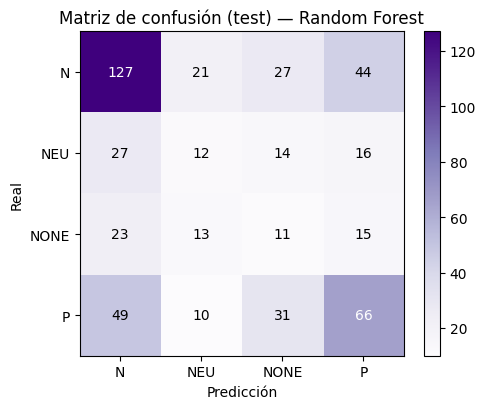

In [10]:
cm=confusion_matrix(y_test,y_pred)
fig,ax=plt.subplots(figsize=(5,4.2)); im=ax.imshow(cm,cmap="Purples")
ax.set_xticks(range(4));ax.set_yticks(range(4));ax.set_xticklabels(le.classes_);ax.set_yticklabels(le.classes_)
for i in range(4):
    for j in range(4): ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else "black")
ax.set_xlabel("Predicción");ax.set_ylabel("Real");ax.set_title(f"Matriz de confusión (test) — {best_name}")
plt.colorbar(im,fraction=0.046); plt.tight_layout(); plt.show()

In [11]:
# Ablación: aporte de cada característica del grupo (quitándola de la unión, con LR)
class Drop(GroupLexical):
    def __init__(self,drop=-1): self.drop=drop
    def transform(self,X,y=None):
        M=super().transform(X); return np.delete(M,self.drop,axis=1) if self.drop>=0 else M
def cv_lr(drop=-1):
    feats=FeatureUnion([("t",make_tfidf()),("l",Pipeline([("e",Drop(drop=drop)),("s",StandardScaler())]))])
    p=ImbPipeline([("f",feats),("ros",RandomOverSampler(random_state=SEED)),("c",LogisticRegression(max_iter=2000,C=1.0,random_state=SEED))])
    return cross_val_score(p,raw_train,y_train,scoring="f1_macro",cv=skf,n_jobs=-1).mean()
full=cv_lr(-1)
pd.DataFrame(sorted([{"característica":n,"Δ macro-F1 al quitarla (pts)":round((full-cv_lr(i))*100,2)}
                     for i,n in enumerate(GroupLexical.names)],key=lambda x:-x["Δ macro-F1 al quitarla (pts)"]))

,característica,Δ macro-F1 al quitarla (pts)
0,vulgarity_count,0.43
1,diminutive_count,-0.09
2,eh_count,-0.40


In [12]:
# Comparación con el baseline TF-IDF solo (test una vez) y análisis de errores
bl=ImbPipeline([("t",make_tfidf()),("ros",RandomOverSampler(random_state=SEED)),("c",LogisticRegression(max_iter=2000,C=1.0,random_state=SEED))]).fit(raw_train,y_train)
f1_bl=f1_score(y_test,bl.predict(raw_test),average="macro")
print(f"Baseline TF-IDF solo (LR): {f1_bl*100:.2f}%   |   Unión + {best_name}: {test_f1*100:.2f}%")
print(f"Referencia TASS 2018 ES (mejor oficial elirf-es-run-1): 50.3%\n")
err=[i for i in range(len(y_test)) if y_pred[i]!=y_test[i]]
print(f"Errores: {len(err)}/{len(y_test)}. Confusiones más frecuentes:")
for (a,b),n in Counter((le.classes_[y_test[i]],le.classes_[y_pred[i]]) for i in err).most_common(6):
    print(f"  {a:>4} -> {b:<4}: {n}")
print("\n10 ejemplos mal clasificados:")
for i in err[:10]:
    print(f"[{le.classes_[y_test[i]]:>4}->{le.classes_[y_pred[i]]:<4}] {raw_test.iloc[i][:90].replace(chr(10),' ')}")

Baseline TF-IDF solo (LR): 37.42%   |   Unión + Random Forest: 33.97%
Referencia TASS 2018 ES (mejor oficial elirf-es-run-1): 50.3%

Errores: 290/506. Confusiones más frecuentes:
     P -> N   : 49
     N -> P   : 44
     P -> NONE: 31
   NEU -> N   : 27
     N -> NONE: 27
  NONE -> N   : 23

10 ejemplos mal clasificados:
[   P->N   ] @piscolabisaereo @HistoriaNG @SPosteguillo las tengo pero aún no las he leído. Caerán pron
[   P->N   ] Al final han sido 3h  Bueno, mañana tengo fiesta así que.. No me quejo
[   P->N   ] Tengo una perrina adorable... Sabéis que me acompaña hasta la a habitación cuando me voy a
[ NEU->NONE] @juankipua Es que en el Ojeando el año pasado tampoco, tiene muchas canciones ya jajajajaj
[   P->NONE] @agcasti y el caminante ante el mar de niebla, uno de mis cuadros favoritos en portada
[   P->N   ] @vitojph ¡sí! Y me ha encantado  ¿Tú ya las visto? ¿Cuándo comentamos?
[NONE->N   ] @aladroqe Se me olvidaban los grandes @2qblog y @estapillao ! A ver si os interesa 

## Conclusión
- Las 3 características del grupo (**eh, malsonante, diminutivos**) aportan una señal modesta que **mejora al
  TF-IDF en CV** cuando se controla el clasificador (LR); de ellas, **`vulgarity_count`** es la que más suma
  (ablación) y es un marcador limpio de **N**.
- Por macro-F1 en CV se elige **Random Forest**, pero su brecha CV→test revela **sobreajuste**; **Regresión
  Logística** es la opción estable recomendada. El **TF-IDF es un baseline fuerte** en este corpus pequeño.
- Cuello de botella: **NEU/NONE** (sin polaridad marcada) y la baja frecuencia de los rasgos léxicos.
- **Pendiente para Julián:** ampliar el análisis (p. ej. su característica), y afinar la parte experimental
  que él trabajó. Este notebook corre de inicio a fin y sirve de base.